# Задание по Python DA: Statistics. Zahoruiko Anna

## 2.  Описательная статистика
### 2.1. Рассчитайте сводную статистику для числовых полей (среднее значение, медиана, режим, диапазон).

In [2]:
# импорт библиотек

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

In [3]:
# Загружаем обратно данных из файла pickle

with open("data.pickle", "rb") as f:
    df_calls, df_contacts, df_deals, df_spend = pickle.load(f)

print("Датафреймы успешно загружены")

Датафреймы успешно загружены


### 2.1.1. Рассчитаем сводную статистику для числовых полей в таблице Calls

In [4]:
print(df_calls.info(), "\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95874 entries, 0 to 95873
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Call_ID               95874 non-null  string        
 1   Call_Start_Time       95874 non-null  datetime64[ns]
 2   Manager               95874 non-null  string        
 3   Contact_ID            95874 non-null  string        
 4   Call Type             95874 non-null  category      
 5   Call_Duration_sec     95874 non-null  int64         
 6   Call_Status           95874 non-null  category      
 7   Outgoing_Call_Status  95874 non-null  category      
 8   Scheduled_in_CRM      95874 non-null  category      
dtypes: category(4), datetime64[ns](1), int64(1), string(3)
memory usage: 4.0 MB
None 



In [5]:
df_calls["Call_Duration_sec"].describe()

count    95874.000000
mean       164.866283
std        401.254951
min          0.000000
25%          4.000000
50%          8.000000
75%         97.000000
max       7625.000000
Name: Call_Duration_sec, dtype: float64

#### **Aнализ сводной статистики числовых полей в таблице Calls:**
- Средняя длительность звонка: 164.86 секунд.
- Медиана (50-й перцентиль): 8 секунд, что говорит о том, что большинство звонков короткие.
- Размах (от 0 до 7625 секунд): Значительный разброс, есть как очень короткие, так и очень длинные звонки.
- 75-й перцентиль: 97 секунд, что говорит о том, что 75% звонков длятся менее 97 секунд.

**Вывод:** Основная масса звонков очень короткие, но есть некоторые значительно более длительные звонки.

### 2.1.2. Рассчитаем сводную статистику для числовых полей в таблице Contacts

In [6]:
print(df_contacts.info(), "\n")

<class 'pandas.core.frame.DataFrame'>
Index: 18547 entries, 0 to 18547
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Contact_ID     18547 non-null  string        
 1   Manager        18547 non-null  string        
 2   Created_Time   18547 non-null  datetime64[ns]
 3   Modified_Time  18547 non-null  datetime64[ns]
dtypes: datetime64[ns](2), string(2)
memory usage: 724.5 KB
None 



**Cводная статистика не может быть рассчитана, поскольку таблица не содержит чиловых полей**

### 2.1.3. Рассчитаем сводную статистику для числовых полей в таблице Spend

In [7]:
print(df_spend.info(), "\n")
df_spend.loc[:, ~df_spend.columns.isin(['Date'])].describe() # использовала оператор отрицания ~

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19862 entries, 0 to 19861
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            19862 non-null  datetime64[ns]
 1   Source          19862 non-null  category      
 2   Campaign        19862 non-null  category      
 3   Impressions     19862 non-null  Int64         
 4   Spend           19862 non-null  float64       
 5   Clicks          19862 non-null  Int64         
 6   Ad_Group        19862 non-null  category      
 7   Ad              19862 non-null  category      
 8   Clicks_Anomaly  19862 non-null  boolean       
 9   CTR             15028 non-null  Float64       
 10  CPC             11971 non-null  Float64       
 11  CPM             15028 non-null  Float64       
dtypes: Float64(3), Int64(2), boolean(1), category(4), datetime64[ns](1), float64(1)
memory usage: 1.3 MB
None 



,Impressions,Spend,Clicks,CTR,CPC,CPM
count,19862.0,19862.000000,19862.0,15028.0,11971.0,15028.0
mean,2571.695197,7.528117,25.095912,1.739956,0.681937,15.441618
std,11691.227016,27.325150,87.032314,4.728463,0.915857,57.240118
min,0.0,0.000000,0.0,0.0,0.0,0.0
25%,1.0,0.000000,0.0,0.0,0.240403,3.425111
50%,82.0,0.740000,2.0,0.768957,0.486667,9.707877
75%,760.75,6.160000,13.0,1.740739,0.82,13.958252
max,431445.0,774.000000,2415.0,100.0,26.666667,1558.870968


#### **Aнализ сводной статистики числовых полей в таблице Spend:**
- Количество показов (Impressions): медиана ~82, но распределение сильно скошено: максимум 431445 показов. Это указывает на наличие небольшого числа кампаний с экстремально большими охватами и множества мелких кампаний с минимальным количеством показов.
- Затраты (Spend): иедианное значение крайне низкое (0.74), при этом максимум достигает 774. Основной объём кампаний работает на небольших бюджетах, но есть отдельные дорогостоящие выбросы.
- Клики (Clicks): медиана всего 2 клика на кампанию, максимум 2415. То же самое: большинство кампаний почти не генерируют клики, трафик сосредоточен в отдельных объявлениях.
- Коэффициент кликабельности CTR (Click-Through Rate): cреднее значение 1.74%, медиана близка (0.77%), но встречаются аномальные пики до 100% CTR (вероятно, ошибка или тестовые кампании). Основная масса кампаний работает в диапазоне до 2%.
- Стоимость одного клика CPC (Cost per Click): в среднем 0.68, медиана 0.49. Значит, клики достаточно дешёвые, но распределение имеет длинный хвост (максимум 26.7).
- Стоимость за тысячу показов CPM (Cost per Mille): cреднее 15.4, медиана 9.7. Встречаются дорогие показы (CPM до 1558), что может указывать на низкие объёмы при фиксированных тратах в некоторых кампаниях.

**Вывод:** Данные характеризуются сильной асимметрией: большинство кампаний низкобюджетные с минимальным количеством показов и кликов, тогда как небольшой пул кампаний даёт основную часть охватов и затрат. CTR и CPC находятся в адекватных пределах, но присутствуют аномальные выбросы (100% CTR, крайне высокий CPM), которые стоит дополнительно проверить.

### 2.1.4. Рассчитаем сводную статистику для числовых полей в таблице Deals

In [8]:
print(df_deals.info(), "\n")
df_deals.loc[:, ~df_deals.columns.isin(['Closing_Date', 'Created_Time'])].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19771 entries, 0 to 19770
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Deal_ID                    19771 non-null  string        
 1   Manager_Name               19771 non-null  category      
 2   Closing_Date               13108 non-null  datetime64[ns]
 3   Quality                    19771 non-null  category      
 4   Stage                      19771 non-null  category      
 5   Lost_Reason                19771 non-null  category      
 6   Campaign                   19771 non-null  category      
 7   Content                    19771 non-null  category      
 8   Term                       19771 non-null  category      
 9   Source                     19771 non-null  category      
 10  Product                    19771 non-null  category      
 11  Education_Type             19771 non-null  category      
 12  Crea

,Course_duration,Initial_Amount_Paid_Clean,Offer_Total_Amount_Clean,SLA_seconds
count,3513.000000,4028.0,4291.0,19770.0
mean,10.198691,940.938679,7404.383594,90214.556803
std,1.834505,1343.874567,4533.566297,634325.288855
min,6.000000,0.0,0.0,3.0
25%,11.000000,300.0,3500.0,7185.75
50%,11.000000,1000.0,11000.0,19165.0
75%,11.000000,1000.0,11000.0,48667.75
max,11.000000,11000.0,11500.0,26908464.0


#### **Aнализ сводной статистики числовых полей в таблице Deals:**
- Course_duration: в основном фиксированная длительность обучения - 11 месяцев (медиана и мода совпадают), минимальное значение — 6 месяцев. Это указывает на стандартизированные форматы курсов.
- Initial_Amount_Paid_Clean: первый платеж сильно варьируется — от 0 до 11000, медиана равна 1000. Есть значительные выбросы.
- Offer_Total_Amount_Clean: полная стоимость курсов в среднем около 7400, но медиана равна 11000 - большинство программ дорогие, но распределение смещено вниз из-за нулевых/льготных сделок.
- SLA_seconds: медиана 19770 секунд (5,3 часа), но встречаются экстремальные значения до 311 дней. Среднее сильно завышено выбросами, реальное распределение ближе к быстрой обработке (<1 дня).

**Выводы:** 
- Большинство сделок ориентированы на стандартные продукты (11-ти месячные курсы).
- Платежное поведение неравномерно: у части клиентов первый платеж символический или отсутствует, что может быть связано с акциями/рассрочкой.
- Сильная разница между предложенной и реально внесенной суммой (много нулевых или частичных оплат) указывает на высокий процент незавершенных или льготных сделок.
- SLA демонстрирует нестабильность: в типичных случаях обработка заявок занимает часы, но система фиксирует и аномальные значения в десятки миллионов секунд. Это требует очистки данных.

### 2.2. Анализируйте категориальные поля, такие как качество, стадия, источник и продукт.
### 2.2.1. Выбор полей для таблицы Contacts
- **Contact Owner Name:** анализ распределения количеству контактов по лицам, ответственным за звонок.

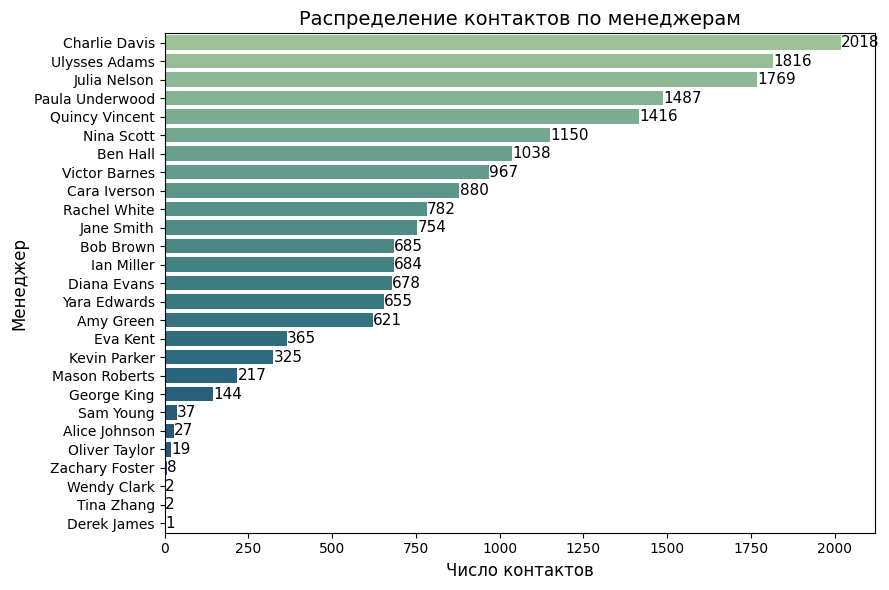

In [9]:
contacts_per_manager = df_contacts["Manager"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(9,6)) 
sns.barplot(
    x=contacts_per_manager.values, 
    y=contacts_per_manager.index, 
    hue=contacts_per_manager.index, 
    palette="crest", 
    dodge=False, 
    legend=False
)

plt.title("Распределение контактов по менеджерам", fontsize=14)
plt.xlabel("Число контактов", fontsize=12)
plt.ylabel("Менеджер", fontsize=12)

for i, v in enumerate(contacts_per_manager.values):
    plt.text(v + 0.5, i, str(v), va="center", fontsize=11)

plt.tight_layout()
plt.show()


**ВЫВОД:**

Анализ распределения контактов по менеджерам показал значительную неоднородность нагрузки. Три менеджера — Charlie Davis, Ulysses Adams и Julia Nelson — обрабатывают наибольшее количество контактов (от 1769 до 2018), в то время как несколько менеджеров (например, Derek James, Tina Zhang) имеют минимальное количество контактов (1–2). Это может свидетельствовать о неравномерном распределении рабочих задач и потенциальной необходимости оптимизации загрузки команды.

### 2.2.2. Выбор категориальных полей для таблицы Calls
- **Call Type**: анализ типов звонков (входящие/исходящие) поможет понять, какие звонки чаще приводят к положительным результатам.
- **Call Status**: анализ статусов звонков (успешный/пропущенный и т.д.) даст представление о качестве взаимодействия с клиентами.

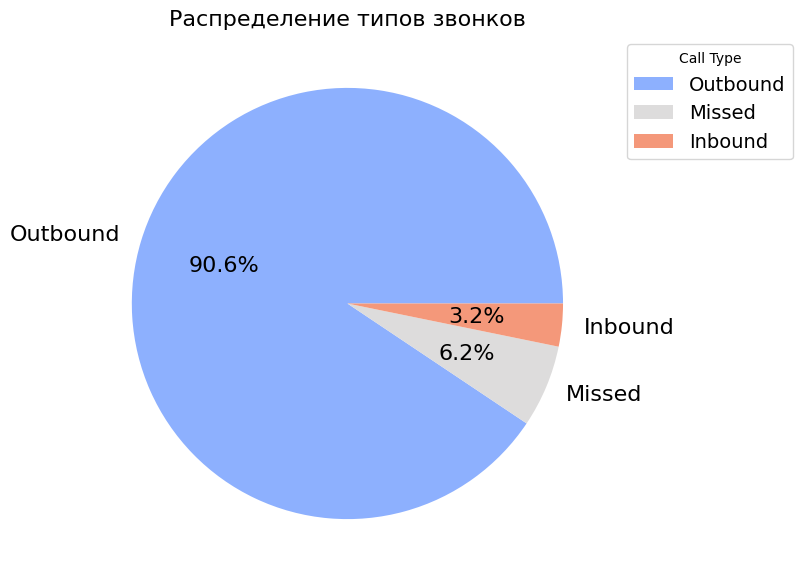

In [37]:
call_type_counts = df_calls['Call Type'].value_counts()

def autopct_format(pct):
    return f"{pct:.1f}%" 

plt.figure(figsize=(10, 7))
wedges, texts, autotexts = plt.pie(
    call_type_counts,
    labels=call_type_counts.index,
    autopct=autopct_format,
    colors=sns.color_palette('coolwarm', len(call_type_counts)),
    textprops={'fontsize': 16}  
)

plt.title('Распределение типов звонков', fontsize=16)
plt.legend(call_type_counts.index, title="Call Type", bbox_to_anchor=(1, 1), loc="upper left", fontsize=14)

plt.show()

**ВЫВОД:**

Анализ распределения типов звонков из таблицы Calls показывает ярко выраженное преобладание исходящих звонков (Outbound), на которые приходится 90,6% всех взаимодействий. Пропущенные звонки (Missed) составляют 6,2%, а входящие (Inbound) — лишь 3,2%.
Это свидетельствует о преимущественно инициативной модели коммуникации с клиентами, где основная активность исходит от сотрудников компании. Низкая доля входящих звонков может указывать на ограниченную реакцию со стороны клиентов или специфику бизнес-модели. Доля пропущенных звонков остаётся умеренной, но требует дополнительного контроля, чтобы не снижать качество обслуживания.

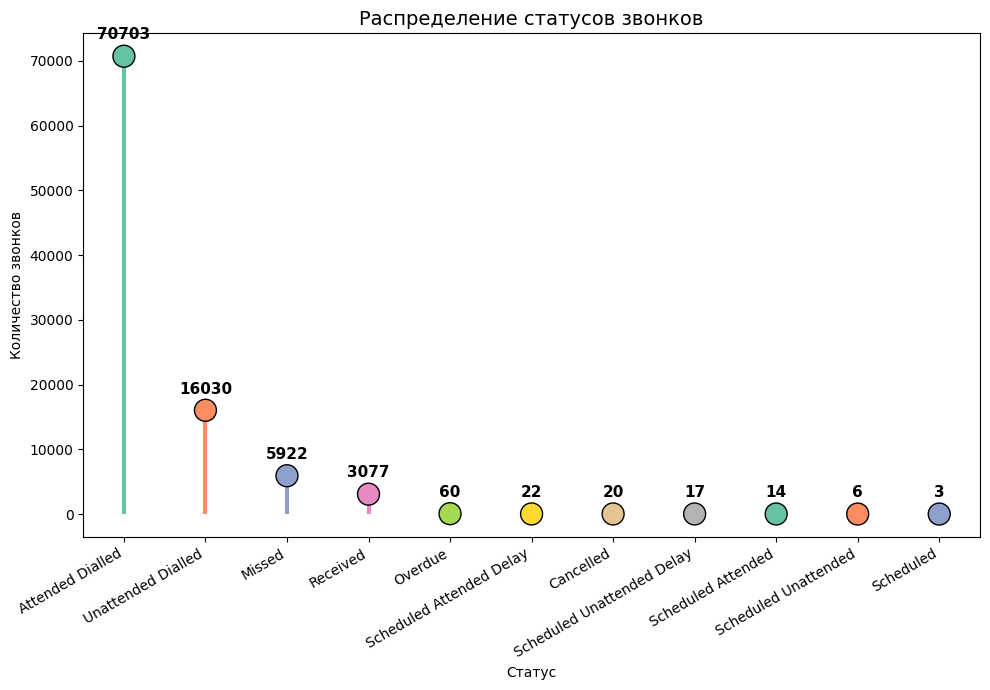

In [42]:
call_status_counts = df_calls["Call_Status"].value_counts().drop("Unknown", errors="ignore")
call_status_counts = call_status_counts.sort_values(ascending=False)

call_status_counts = df_calls["Call_Status"].value_counts().drop("Unknown", errors="ignore")
call_status_counts = call_status_counts.sort_values(ascending=False)

colors = sns.color_palette("Set2", n_colors=len(call_status_counts))

plt.figure(figsize=(10,7)) 

plt.vlines(x=call_status_counts.index, ymin=0, ymax=call_status_counts.values, 
           color=colors, lw=3)

plt.scatter(x=call_status_counts.index, y=call_status_counts.values, 
            s=250, color=colors, zorder=3, edgecolor="black", linewidth=1)

plt.title("Распределение статусов звонков", fontsize=14)
plt.xlabel("Статус")
plt.ylabel("Количество звонков")

plt.xticks(rotation=30, ha="right")

for i, (cat, val) in enumerate(call_status_counts.items()):
    plt.text(i, val + (max(call_status_counts.values)*0.03), str(val), 
             ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

**ВЫВОД:**

Распределение по статусам звонков демонстрирует явное доминирование двух основных категорий:
Attended Dialled — 70703 звонка; Unattended Dialled — 16030 звонков. Это указывает на то, что подавляющее большинство звонков было исходящими с попыткой дозвона, при этом значительная часть была неуспешной (Unattended).
Также обращает на себя внимание:
Missed — 5922 пропущенных звонка, что требует отдельного контроля в рамках клиентского сервиса; Received — лишь 3077 звонков, что подтверждает вывод из анализа Call Type: компания преимущественно инициирует контакт. Оставшиеся категории (запланированные, отменённые и с задержкой) составляют незначительную долю, что может говорить о низкой активности планирования звонков через CRM или малом объёме подобных сценариев.

### 2.2.3. Выбор категориальных полей для таблицы Spend
- Проанализируем данные **по суммам Spend по каждому каналу Source** и построим график, который показывает суммарные значения Spend для каждого источника

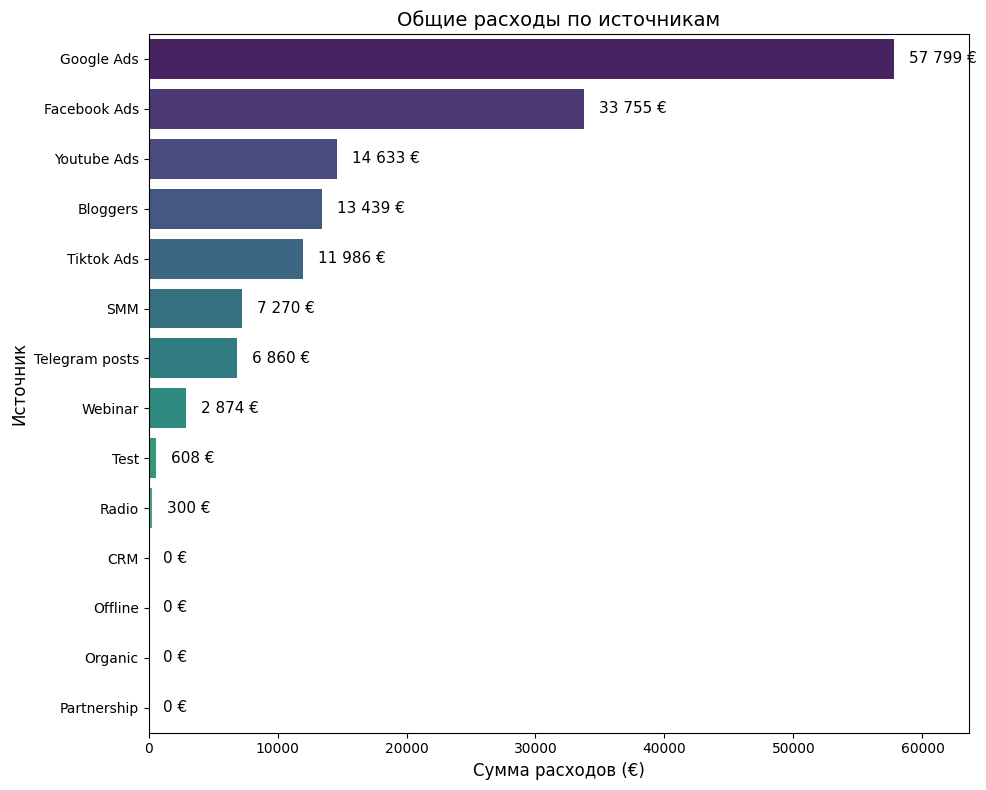

In [41]:
if "Spend" in df_spend.columns:
    df_spend["Spend"] = pd.to_numeric(df_spend["Spend"], errors="coerce")

spend_by_source = (
    df_spend.groupby("Source", observed=True)["Spend"]
    .sum()
    .drop("Unknown", errors="ignore")
    .reset_index()
)

spend_by_source = spend_by_source.sort_values(by="Spend", ascending=False)
order = spend_by_source["Source"].tolist()

plt.figure(figsize=(10,8))
ax = sns.barplot(
    data=spend_by_source,
    x="Spend",
    y="Source",
    order=order,
    hue="Source",
    hue_order=order,
    dodge=False,
    legend=False,
    palette="viridis"
)

plt.title("Общие расходы по источникам", fontsize=14)
plt.xlabel("Сумма расходов (€)", fontsize=12)
plt.ylabel("Источник", fontsize=12)

xmax = spend_by_source["Spend"].max() if not spend_by_source.empty else 0
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height()/2
    ax.text(
        width + (xmax * 0.02 if xmax > 0 else 0.1),
        y,
        f"{width:,.0f} €".replace(",", " "),  # формат с €
        va="center",
        ha="left",
        fontsize=11
    )

ax.set_xlim(0, xmax * 1.1 if xmax > 0 else 1)

plt.tight_layout()
plt.show()

**ВЫВОД:**

Наибольшие расходы приходятся на Google Ads (57 799 €) и Facebook Ads (33 755 €) — эти два канала формируют основной объём затрат, заметно опережая все остальные источники. Средний уровень расходов наблюдается у YouTube Ads, Bloggers и TikTok Ads (в диапазоне 11–15 тыс. €), что указывает на их значимость, но меньшую роль по сравнению с лидерами. Остальные каналы (SMM, Telegram, Webinar и ниже) занимают маргинальную долю бюджета, а такие источники как CRM, Offline, Organic и Partnership вовсе не потребовали расходов.

Таким образом, распределение бюджета демонстрирует явную концентрацию средств в нескольких крупных каналах (Google и Facebook), при этом значительная часть источников либо недофинансируется, либо не используется вовсе. Это может указывать как на стратегический выбор приоритета высокоэффективных каналов, так и на возможные точки роста за счёт диверсификации вложений в недоиспользуемые источники.

### 2.2.4. Выбор категориальных полей для таблицы Deals
- **Quality:** aнализ качества лидов помогает выявить, какие категории лидов наиболее ценные для бизнеса, а также определить области для улучшения в процессе привлечения и обработки лидов.
- **Stage:** aнализ стадий сделок поможет выявить узкие места в процессе продаж и понять, где теряются потенциальные клиенты.
- **Source:** aнализ источников сделок позволит определить, какие каналы маркетинга наиболее эффективны.
- **Product:** анализ конкретных продуктов позволит определить, какие услуги чаще всего участвуют в сделках.

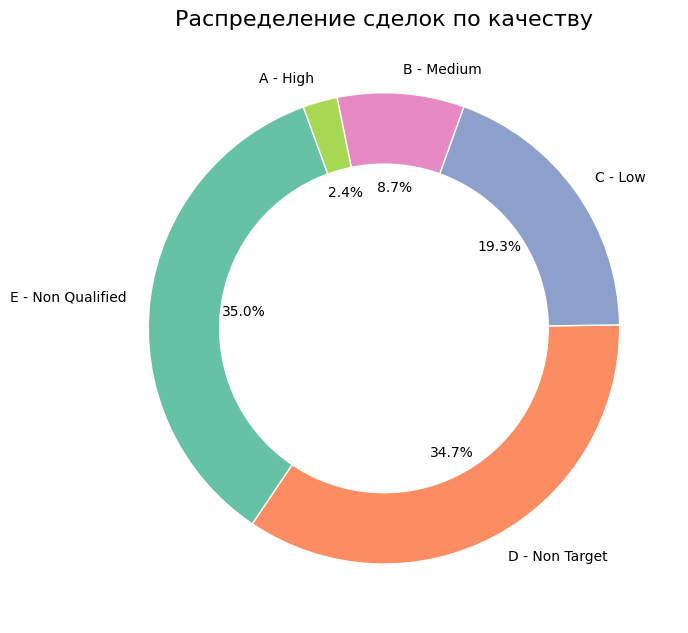

In [60]:
s = df_deals["Quality"].dropna().astype(str).str.strip()
s = s[~s.str.lower().isin(["unknown", ""])]

counts = s.value_counts()
if counts.empty:
    print("Распределение сделок по качеству: данных нет")
else:
    plt.figure(figsize=(7,7))
    wedges, texts, autotexts = plt.pie(
        counts,
        labels=counts.index,
        autopct="%1.1f%%",
        startangle=110,
        wedgeprops=dict(width=0.5, edgecolor="w"),
        colors=sns.color_palette("Set2", n_colors=len(counts))
    )
    plt.gca().add_artist(plt.Circle((0,0), 0.70, fc="white"))
    plt.title("Распределение сделок по качеству", fontsize=16)
    plt.tight_layout()
    plt.show()

**Наблюдения:**

Самая большая доля приходится на категории D–Non Target (34.7%) и E–Non Qualified (35.0%). То есть почти 70% всех сделок изначально низкого качества, либо нецелевые, либо неподходящие.
Категория C–Low (19.3%) занимает почти пятую часть сделок, что также свидетельствует о слабом уровне лидов.
Более ценные сделки (B–Medium и A–High) составляют всего 11% (8.7% + 2.4%).

**ВЫВОД:**
Качество лидов в целом низкое: подавляющее большинство сделок не имеет высокой ценности для бизнеса. Это может указывать либо на недостаточно точный таргетинг маркетинговых кампаний, либо на неэффективную систему фильтрации входящих заявок.

**Рекомендации:**
- Усилить работу с источниками лидов: провести анализ, из каких именно каналов чаще всего приходят Non Target и Non Qualified, и скорректировать маркетинговую стратегию.
- Оптимизировать фильтрацию: внедрить более строгие критерии отбора лидов на ранних этапах.
- Фокус на качественных сегментах: перераспределить усилия и бюджет в каналы, которые дают сделки хотя бы категории B и A.
- Совместить с анализом Stage: проверить, проходят ли лиды категории B и A успешнее по воронке продаж, чтобы подтвердить гипотезу о более высокой ценности.

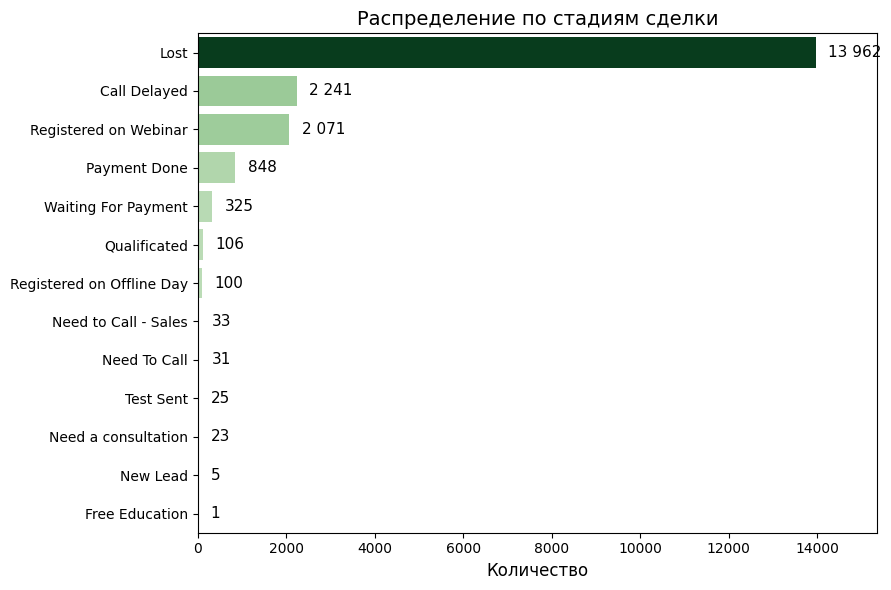

In [76]:
s = df_deals["Stage"].dropna().astype(str).str.strip()
s = s[~s.str.lower().isin(["unknown", ""])]

counts = s.value_counts()
if counts.empty:
    print("Распределение по стадиям сделки: данных нет")
else:
    df_counts = counts.reset_index()
    df_counts.columns = ["category", "count"]
    df_counts = df_counts.sort_values(by="count", ascending=False)
    order = df_counts["category"].tolist()

    max_count = df_counts["count"].max()
    min_count = df_counts["count"].min()
    norm_counts = (df_counts["count"] - min_count) / (max_count - min_count + 1e-9) 
    colors = [sns.color_palette("Greens", as_cmap=True)(0.3 + 0.7*val) for val in norm_counts] 

    plt.figure(figsize=(9,6))
    ax = sns.barplot(
        data=df_counts,
        x="count",
        y="category",
        order=order,
        hue="category",    
        dodge=False,
        palette=colors,
        legend=False
    )

    plt.title("Распределение по стадиям сделки", fontsize=14)
    plt.xlabel("Количество", fontsize=12)
    plt.ylabel("", fontsize=12)

    xmax = df_counts["count"].max()
    for p in ax.patches:
        width = p.get_width()
        y = p.get_y() + p.get_height()/2
        ax.text(width + (xmax * 0.02), y, f"{int(width):,}".replace(",", " "), va="center", ha="left", fontsize=11)

    ax.set_xlim(0, xmax * 1.1)
    plt.tight_layout()
    plt.show()

**Наблюдения:**

Подавляющее большинство сделок (13962) находится в статусе Lost – это более 70–80% всех записей. Следующие по объёму стадии — Call Delayed (2241) и Registered on Webinar (2071). Это относительно крупные кластеры, но они значительно уступают числу потерянных сделок. На финальных стадиях воронки, связанных с успешным закрытием (Payment Done — 848, Qualified — 106), остаётся крайне малая часть от общего потока. Остальные категории (Need to Call, Consultation, Test Sent и др.) встречаются единично и не оказывают существенного влияния.

**ВЫВОД:**

Воронка продаж сильно «проседает» — большая часть лидов теряется, и лишь малая доля доходит до оплаты. Это подтверждает предыдущий анализ по Quality, где значительная доля сделок была Non Target и Non Qualified. Вероятно, бизнес тратит ресурсы на обработку низкокачественных лидов, что приводит к высоким потерям на этапе продаж.

**Рекомендации:**
- Фокус на верх воронки: пересмотреть стратегию генерации лидов и увеличить долю качественных (A и B) клиентов, чтобы снизить число «Lost».
- Анализ причин отказов: проработать поле Lost Reason, чтобы выявить системные проблемы (например, неподходящий продукт, цена, тайминг или низкий интерес).
- Работа с отложенными лидами: категории Call Delayed и Registered on Webinar показывают, что часть клиентов всё же проявляет интерес, но не доходит до оплаты. Здесь можно внедрить доработку скриптов и систему повторных касаний.
- Оптимизация конверсии: проверить, на каких этапах (между Webinar - Payment или Call - Payment) происходит максимальный отток, и сосредоточиться на устранении барьеров.

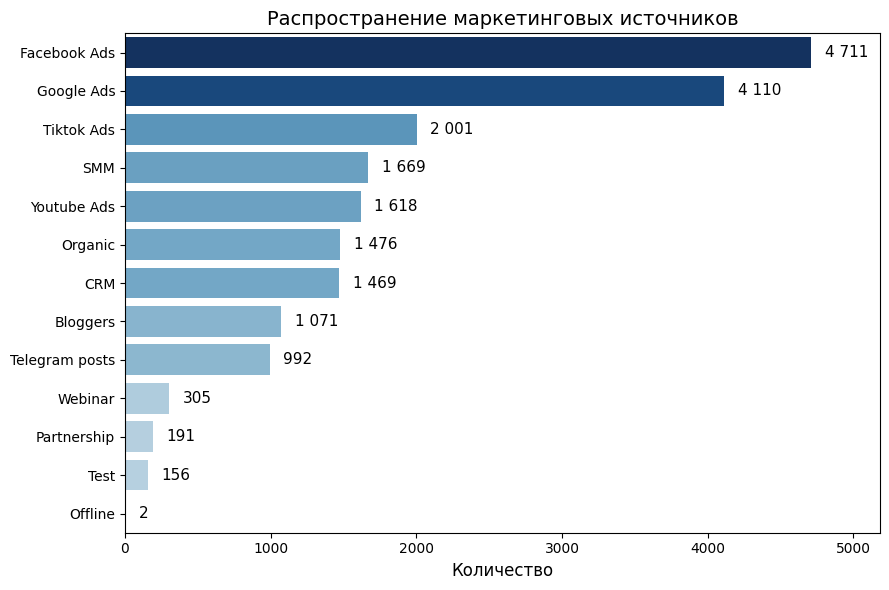

In [72]:
s = df_deals["Source"].dropna().astype(str).str.strip()
s = s[~s.str.lower().isin(["unknown", ""])]

counts = s.value_counts()
if counts.empty:
    print("Распространение маркетинговых источников: данных нет")
else:
    df_counts = counts.reset_index()
    df_counts.columns = ["category", "count"]
    df_counts = df_counts.sort_values(by="count", ascending=False)
    order = df_counts["category"].tolist()

    max_count = df_counts["count"].max()
    min_count = df_counts["count"].min()
    norm_counts = (df_counts["count"] - min_count) / (max_count - min_count + 1e-9)
    colors = [sns.color_palette("Blues", as_cmap=True)(0.3 + 0.7*val) for val in norm_counts]

    plt.figure(figsize=(9,6))
    ax = sns.barplot(
        data=df_counts,
        x="count",
        y="category",
        order=order,
        hue="category",        
        dodge=False,
        palette=colors,
        legend=False
    )

    plt.title("Распространение маркетинговых источников", fontsize=14)
    plt.xlabel("Количество", fontsize=12)
    plt.ylabel("", fontsize=12)

    xmax = df_counts["count"].max()
    for p in ax.patches:
        width = p.get_width()
        y = p.get_y() + p.get_height()/2
        ax.text(width + (xmax * 0.02), y, f"{int(width):,}".replace(",", " "), va="center", ha="left", fontsize=11)

    ax.set_xlim(0, xmax * 1.1)
    plt.tight_layout()
    plt.show()

**Наблюдения:**

Лидерами по количеству сделок являются Facebook Ads (4 711) и Google Ads (4 110) — эти каналы формируют основной поток лидов.
Средний уровень — TikTok Ads (2 001), SMM (1 669), YouTube Ads (1 618), Organic (1 476), CRM (1 469) — эти источники тоже дают значимый вклад.
Более нишевые каналы: Bloggers (1 071), Telegram posts (992).
Минимальное количество лидов дают Webinar (305), Partnership (191), Test (156), Offline (2) — практически не влияют на общую картину.

**ВЫВОД:**
Распределение источников показывает сильную зависимость от двух крупных каналов (Facebook и Google Ads), тогда как остальные источники выполняют поддерживающую роль. Такая концентрация повышает риски: при снижении эффективности одного из этих каналов бизнес может столкнуться с резким падением числа сделок.

**Рекомендации:**
- Сфокусироваться на анализе качества лидов по источникам: количество ≠ качество. Нужно проверить, какая доля лидов из Facebook и Google реально доходит до стадии Payment Done.
- Оценить стоимость лида по источникам: возможно, более «малые» каналы (например, Organic или CRM) приносят более дешёвых и качественных клиентов.
- Диверсифицировать маркетинг: стоит протестировать увеличение инвестиций в средние по объёму каналы (TikTok, SMM, YouTube), чтобы снизить зависимость от двух лидеров.

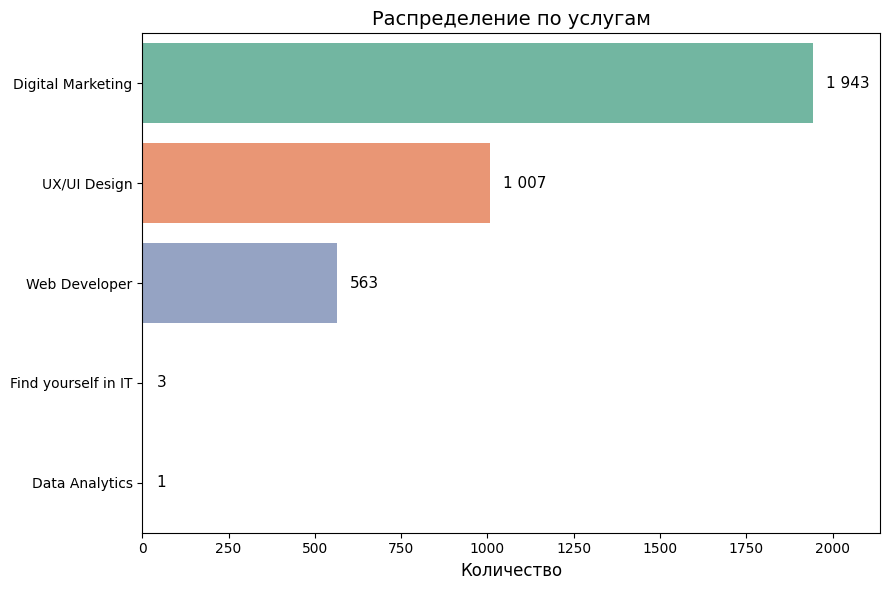

In [80]:
s = df_deals["Product"].dropna().astype(str).str.strip()
s = s[~s.str.lower().isin(["unknown", ""])]

counts = s.value_counts()
if counts.empty:
    print("Распределение по услугам: данных нет")
else:
    df_counts = counts.reset_index()
    df_counts.columns = ["category", "count"]
    df_counts = df_counts.sort_values(by="count", ascending=False)
    order = df_counts["category"].tolist()

    plt.figure(figsize=(9,6))
    ax = sns.barplot(
        data=df_counts,
        x="count",
        y="category",
        order=order,
        hue="category",
        hue_order=order,
        dodge=False,
        legend=False,
        palette="Set2"
    )
    plt.title("Распределение по услугам", fontsize=14)
    plt.xlabel("Количество", fontsize=12)
    plt.ylabel("", fontsize=12)

    xmax = df_counts["count"].max()
    for p in ax.patches:
        width = p.get_width()
        y = p.get_y() + p.get_height()/2
        ax.text(width + (xmax * 0.02), y, f"{int(width):,}".replace(",", " "), va="center", ha="left", fontsize=11)

    ax.set_xlim(0, xmax * 1.1)
    plt.tight_layout()
    plt.show()

**ВЫВОД:** Основной фокус бизнеса сосредоточен вокруг Digital Marketing и UX/UI Design — именно эти услуги являются драйверами сделок. Остальные продукты занимают нишевую позицию, а часть (например, Data Analytics) фактически не работает.

**Рекомендации:**
- Оценить эффективность лидеров (Digital Marketing, UX/UI Design): проверить не только количество сделок, но и конверсию в оплату, чтобы убедиться, что большой поток лидов действительно приносит доход.
- Анализировать потенциал Web Developer: продукт занимает 3-е место и может быть точкой роста при усилении маркетинга.
- Рассмотреть стратегию по Find yourself in IT и Data Analytics: либо отказаться от продвижения нерелевантных программ, либо провести глубокий аудит (почему они не продаются: нет спроса, слабый маркетинг или продукт не доработан).
- Диверсификация продуктовой линейки: если бизнес хочет снизить риски зависимости от одного продукта, стоит тестировать новые направления или усиливать слабые.